# MOD-IV Shore Parcels — EDA

In [5]:
import geopandas as gpd
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path


import os
os.chdir('/Volumes/SSD/climate-risk')

DATA = Path("data")
SHORE_PATH = DATA / "parcels_shore.parquet"

# Schema — no data loaded
schema = pq.read_schema(SHORE_PATH)
print(f"Rows (all years): {pq.read_metadata(SHORE_PATH).num_rows:,}")
print(f"Columns: {len(schema)}\n")
for field in schema:
    print(f"  {field.name:<45} {field.type}")

Rows (all years): 6,779,800
Columns: 187

  mod_iv_recordid                               string
  mun_code_id                                   string
  mod_iv_county_name                            string
  mod_iv_munis_name                             string
  gis_pin                                       string
  county_district                               string
  property_id_blk                               string
  property_id_lot                               string
  property_id_qualifier                         string
  qualification_code_name                       string
  record_id                                     string
  sub_record_id                                 string
  last_trans_date_MMDDYY                        string
  last_trans_update_number                      string
  tax_acct_number                               string
  property_class                                string
  property_class_code_name                      string
  property_location    

In [2]:
# Load one year for a quick look at actual data
sample = gpd.read_parquet(SHORE_PATH, filters=[("mod_iv_year", "==", 2023)])
print(f"2023 rows: {len(sample):,}  |  CRS: {sample.crs.to_epsg()}")
sample.head(3)

2023 rows: 442,588  |  CRS: 8760


,mod_iv_recordid,mun_code_id,mod_iv_county_name,mod_iv_munis_name,gis_pin,county_district,property_id_blk,property_id_lot,property_id_qualifier,qualification_code_name,...,bd_material,bd_style,bd_garage_stalls,bd_garage_type,bd_is_condo,bd_is_common_element,bd_unit_floor,bd_is_model_plan,census_tract_geoid,pct_seasonal
0,010801124 00014 21,535,ATLANTIC,Egg Harbor Township,0108_1124_14,0108,1124,14,None,UNKNOWN,...,frame,None,NaN,None,False,False,None,False,34001011702,0.0
1,010801124 00016 20,535,ATLANTIC,Egg Harbor Township,0108_1124_16,0108,1124,16,None,UNKNOWN,...,frame,None,NaN,None,False,False,None,False,34001011702,0.0
2,010801124 00017 20,535,ATLANTIC,Egg Harbor Township,0108_1124_17,0108,1124,17,None,UNKNOWN,...,frame,None,NaN,None,False,False,None,False,34001011702,0.0


In [3]:
df = sample[["property_class", 
             "property_class_code_name",
              "building_description", 
              "land_description",
              "calculated_acreage",
             "additional_lots_1",
             "additional_lots_2",
             "sale_price",
             "sale_year",
             "sale_assessment",
             "number_of_dwellings",
             "building_class_code",
             "building_class_code_dwelling_type",
             "building_class_code_class",
             "year_constructed",
             "land_value",
            "improvement_value",
            "net_taxable_value",
            "property_use_code",
            "property_use_code_name"
             ]].copy()

In [4]:
sample. 

,property_class,property_class_code_name,building_description,land_description,calculated_acreage,additional_lots_1,additional_lots_2,sale_price,sale_year,sale_assessment,number_of_dwellings,building_class_code,building_class_code_dwelling_type,building_class_code_class,year_constructed,land_value,improvement_value,net_taxable_value,property_use_code,property_use_code_name
0,2,Residential,1SF,91 X 110 IRR.,None,None,None,0,2008.0,87300,01,16,Single Family Dwelling,Standard Quality Dwelling,1955,57400,100000,157400,None,No Code
1,2,Residential,1SF,56 X 175,0.22500,None,None,105000,2019.0,70800,01,16,Single Family Dwelling,Standard Quality Dwelling,1955,41000,29800,70800,None,No Code
2,2,Residential,1SF,148 X 175,0.59460,None,None,61900,2005.0,101800,01,16,Single Family Dwelling,Standard Quality Dwelling,1955,45300,115600,160900,None,No Code
3,2,Residential,1SF,100 X 175,0.40170,None,None,1,2016.0,122500,01,16,Single Family Dwelling,Standard Quality Dwelling,1994,43800,78700,122500,None,No Code
4,2,Residential,1SF1G-1SF,225 X 175,0.90390,None,None,1,2002.0,112200,02,16,Single Family Dwelling,Standard Quality Dwelling,1930,47700,141500,189200,None,No Code
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442583,2,Residential,2S-F,1.277AC,1.27700,None,None,0,NaN,0,01,16,Single Family Dwelling,Standard Quality Dwelling,1925,87700,175900,263600,None,No Code
442584,2,Residential,2S-F,.47AC,0.47000,None,OB480L20,0,NaN,0,01,15,Single Family Dwelling,Average Quality Dwelling,1810,84700,133700,218400,None,No Code
442585,2,Residential,1S-F-F-2UG,120X135,0.37190,L2,None,0,NaN,0,01,15,Single Family Dwelling,Average Quality Dwelling,1961,325800,63400,389200,None,No Code
442586,2,Residential,1S-F-F,60X142 IRR,None,L4,None,0,NaN,0,01,14,Single Family Dwelling,Below Average Quality Dwelling,1962,131600,36200,167800,None,No Code


## EDA — Regression Variables

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

NUM_VARS = ["sale_price", "sale_assessment", "year_constructed",
            "land_value", "improvement_value", "net_taxable_value"]

# Cast all to numeric — stored as strings in parquet
df_num = df[NUM_VARS].apply(pd.to_numeric, errors="coerce")

# --- coverage summary ---
n = len(df_num)
summary = pd.DataFrame({
    "dtype":      df_num.dtypes,
    "null_count": df_num.isna().sum(),
    "null_%":     (df_num.isna().mean() * 100).round(1),
    "zero_count": (df_num == 0).sum(),
    "zero_%":     ((df_num == 0).mean() * 100).round(1),
    "min":        df_num.min(),
    "p1":         df_num.quantile(0.01),
    "median":     df_num.median(),
    "mean":       df_num.mean().round(0),
    "p99":        df_num.quantile(0.99),
    "max":        df_num.max(),
})
print(f"Total rows (2023): {n:,}\n")
summary

Total rows (2023): 399,107



,dtype,null_count,null_%,zero_count,zero_%,min,p1,median,mean,p99,max
sale_price,int64,0,0.0,31980,8.0,0.0,0.0,165000.0,292949.0,2300000.0,63191093.0
sale_assessment,int64,0,0.0,35613,8.9,0.0,0.0,183600.0,294746.0,2109994.0,18720900.0
year_constructed,float64,763,0.2,2389,0.6,0.0,1880.0,1974.0,1960.0,2020.0,9999.0
land_value,int64,0,0.0,411,0.1,0.0,10000.0,136300.0,263138.0,2063152.0,27581900.0
improvement_value,int64,0,0.0,386,0.1,0.0,13600.0,150000.0,216816.0,1264394.0,13250900.0
net_taxable_value,int64,0,0.0,82,0.0,0.0,45200.0,311400.0,479860.0,3163276.0,38868300.0


In [7]:
# Arms-length sales only: sale_price > 1000, sale_assessment > 0
# year_constructed: treat 0 as missing
df_clean = df_num.copy()
df_clean["year_constructed"] = df_clean["year_constructed"].replace(0, np.nan)

df_sales = df_clean[df_clean["sale_price"] > 1000].copy()
print(f"Arms-length sales: {len(df_sales):,}  ({len(df_sales)/n*100:.1f}% of all parcels)")

Arms-length sales: 286,840  (71.9% of all parcels)


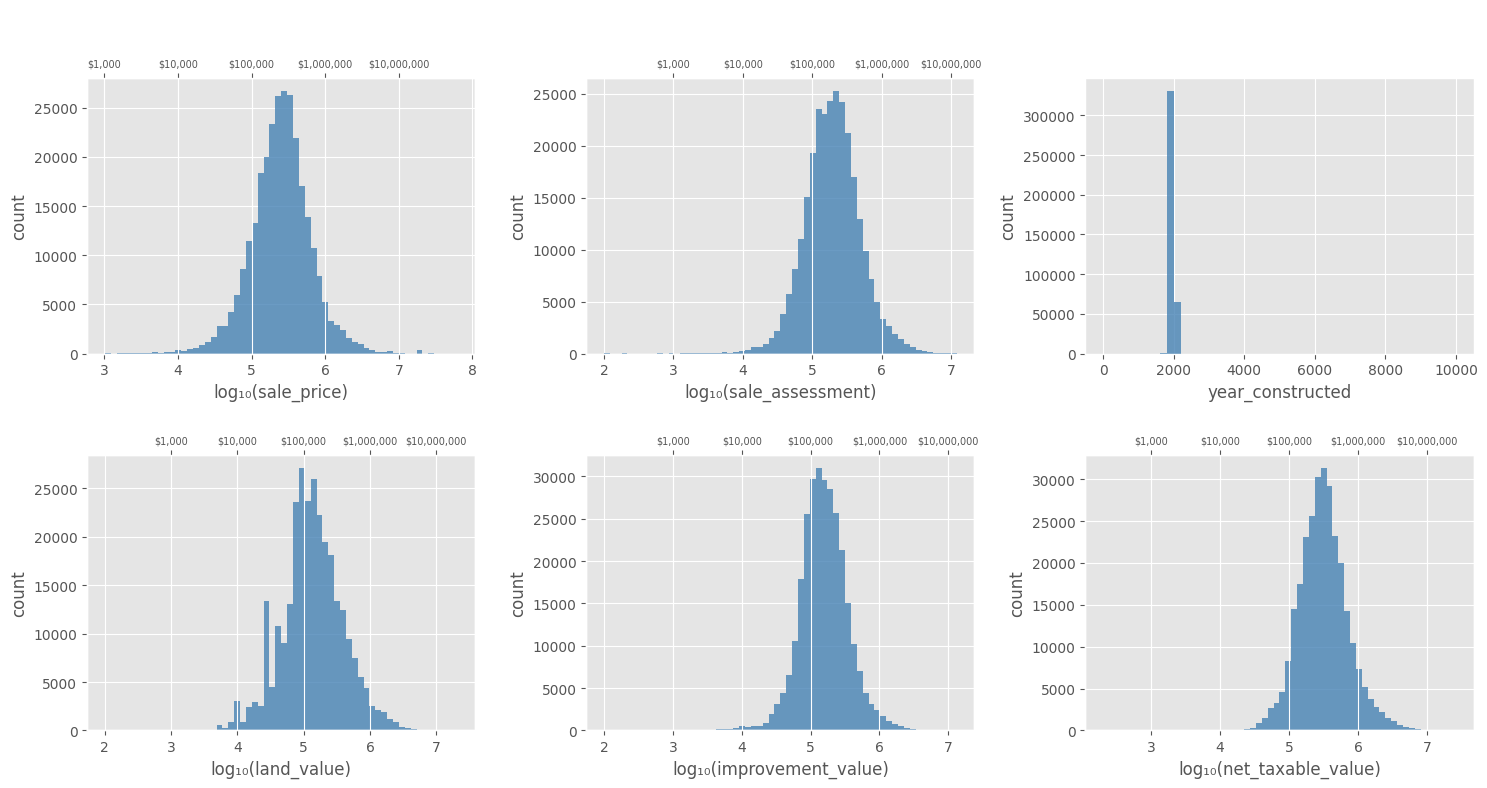

In [8]:
# Distributions — log scale for value vars, linear for year_constructed
VALUE_VARS = ["sale_price", "sale_assessment", "land_value", "improvement_value", "net_taxable_value"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(NUM_VARS):
    ax = axes[i]
    data = df_sales[var].dropna() if var != "year_constructed" else df_clean["year_constructed"].dropna()
    use_log = var != "year_constructed"

    if use_log:
        data = data[data > 0]
        ax.hist(np.log10(data), bins=60, color="steelblue", edgecolor="none", alpha=0.8)
        ax.set_xlabel(f"log₁₀({var})")
        # Add dollar tick labels on top axis
        ticks = [3, 4, 5, 6, 7]
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(ticks)
        ax2.set_xticklabels([f"${10**t:,.0f}" for t in ticks], fontsize=7)
    else:
        ax.hist(data, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
        ax.set_xlabel(var)

    ax.set_title(var, fontsize=10)
    ax.set_ylabel("count")

fig.suptitle("Variable distributions  (sale vars: arms-length only, year_constructed: all parcels)", fontsize=11)
plt.tight_layout()
plt.show()

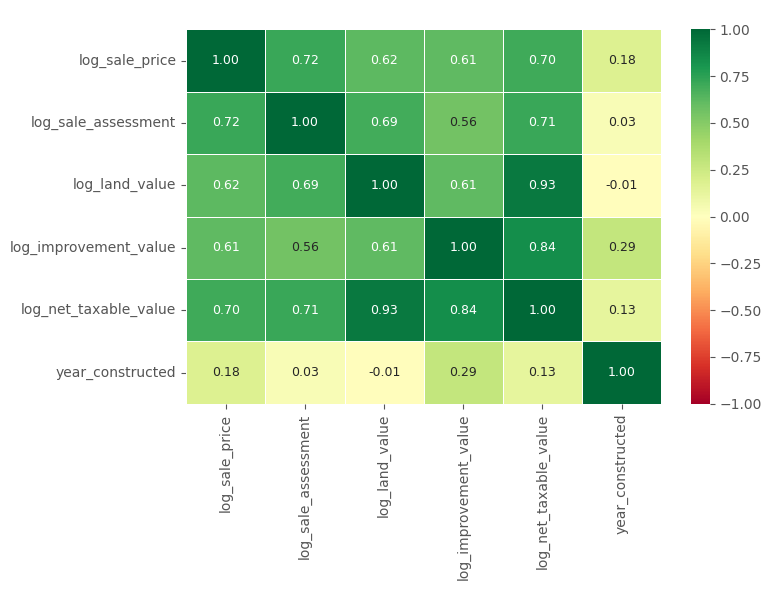

In [9]:
# Correlation matrix — log-transformed value vars, arms-length sales only
log_cols = {v: f"log_{v}" for v in VALUE_VARS}
corr_df = df_sales[VALUE_VARS].copy()
corr_df = corr_df[(corr_df > 0).all(axis=1)]   # drop any zeros before log
corr_df = np.log10(corr_df).rename(columns=log_cols)

# add year_constructed (linear)
corr_df["year_constructed"] = df_clean.loc[corr_df.index, "year_constructed"]

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={"size": 9})
ax.set_title("Pearson correlation  (value vars log₁₀-transformed, arms-length sales)", fontsize=10)
plt.tight_layout()
plt.show()

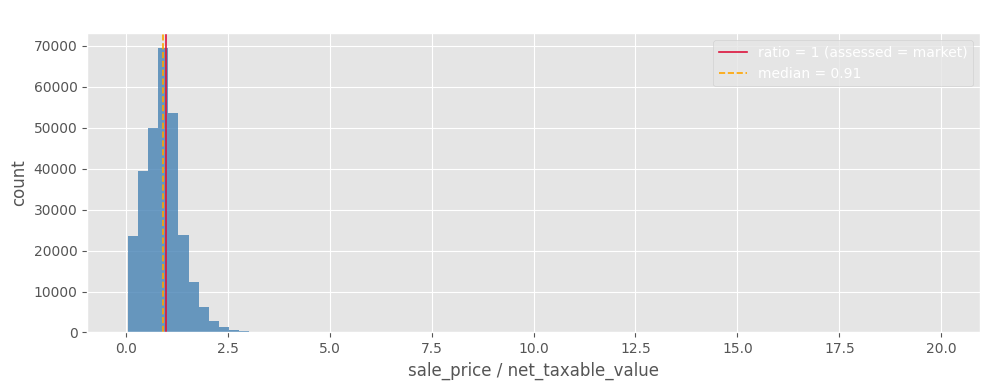

Median sale ratio: 0.914  |  mean: 0.937  |  n=284,734


In [10]:
# Sale ratio (sale_price / net_taxable_value) — key diagnostic for assessment quality
# >1 = under-assessed, <1 = over-assessed relative to market
ratio = df_sales.query("net_taxable_value > 0")["sale_price"] / \
        df_sales.query("net_taxable_value > 0")["net_taxable_value"]
ratio = ratio[(ratio > 0.05) & (ratio < 20)]   # drop extreme outliers

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ratio, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(1.0, color="crimson", linewidth=1.2, label="ratio = 1 (assessed = market)")
ax.axvline(ratio.median(), color="orange", linewidth=1.2, linestyle="--",
           label=f"median = {ratio.median():.2f}")
ax.set_xlabel("sale_price / net_taxable_value")
ax.set_ylabel("count")
ax.set_title("Sale ratio distribution  (arms-length sales, 2023)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Median sale ratio: {ratio.median():.3f}  |  mean: {ratio.mean():.3f}  |  n={len(ratio):,}")

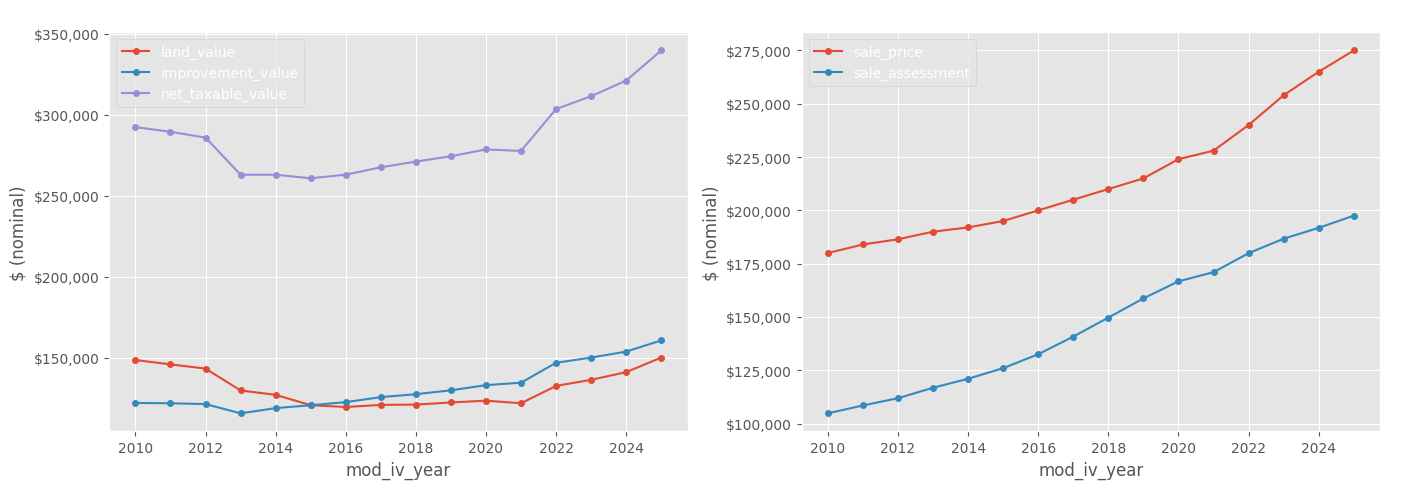

In [11]:
# Year-over-year trends — load all years, compute median values per year
# Reads only the 6 target columns + year (no geometry) → fast
cols_to_load = NUM_VARS + ["mod_iv_year"]
all_years = pd.read_parquet(SHORE_PATH, columns=cols_to_load)
all_years[NUM_VARS] = all_years[NUM_VARS].apply(pd.to_numeric, errors="coerce")
all_years["year_constructed"] = all_years["year_constructed"].replace(0, np.nan)

# Arms-length filter for sale vars
sales_mask = all_years["sale_price"] > 1000
trend_all   = all_years.groupby("mod_iv_year")[["land_value", "improvement_value", "net_taxable_value"]].median()
trend_sales = all_years[sales_mask].groupby("mod_iv_year")[["sale_price", "sale_assessment"]].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trend_all.plot(ax=axes[0], marker="o", markersize=4)
axes[0].set_title("Median assessed values by year  (all parcels)")
axes[0].set_ylabel("$ (nominal)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

trend_sales.plot(ax=axes[1], marker="o", markersize=4)
axes[1].set_title("Median sale price & sale assessment by year  (arms-length only)")
axes[1].set_ylabel("$ (nominal)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

for ax in axes:
    ax.set_xlabel("mod_iv_year")

plt.tight_layout()
plt.show()

## Sale Price Persistence Across Years

`sale_price` in MOD-IV is the most recent recorded sale — it stays frozen until the property sells again. This checks how often it actually changes per parcel.

In [12]:
# Load only what we need — no geometry
panel = pd.read_parquet(SHORE_PATH, columns=["gis_pin", "mod_iv_year", "sale_price"])
panel["sale_price"] = pd.to_numeric(panel["sale_price"], errors="coerce")

# Arms-length only
panel = panel[panel["sale_price"] > 1000].copy()

# Per-parcel stats across years
parcel_stats = panel.groupby("gis_pin").agg(
    years_observed = ("mod_iv_year", "nunique"),
    n_distinct_prices = ("sale_price", "nunique"),
    first_price = ("sale_price", "first"),
    last_price  = ("sale_price", "last"),
).reset_index()

parcel_stats["n_sales_events"] = parcel_stats["n_distinct_prices"]  # each distinct price = a sale event

print(f"Parcels with ≥1 arms-length sale record: {len(parcel_stats):,}\n")
print("Distribution of distinct sale prices per parcel (across all years):")
print(parcel_stats["n_distinct_prices"].value_counts().sort_index().to_frame("parcel_count").assign(
    pct=lambda d: (d["parcel_count"] / d["parcel_count"].sum() * 100).round(1)
))

Parcels with ≥1 arms-length sale record: 340,455

Distribution of distinct sale prices per parcel (across all years):
                   parcel_count   pct
n_distinct_prices                    
1                        193428  56.8
2                        107737  31.6
3                         32567   9.6
4                          5972   1.8
5                           696   0.2
6                            53   0.0
7                             2   0.0


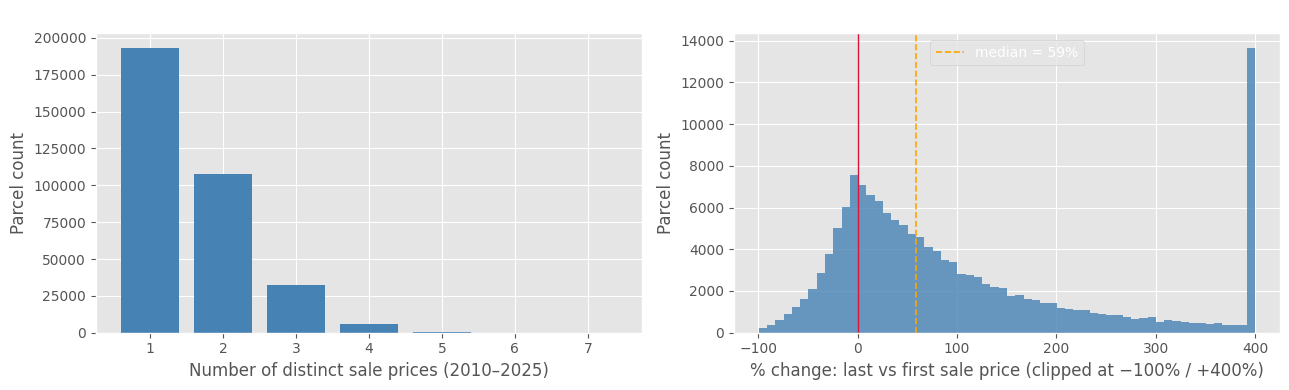

In [13]:
# Visualise: how many parcels never change vs change once vs multiple times
counts = parcel_stats["n_distinct_prices"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart of sale event counts
axes[0].bar(counts.index, counts.values, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Number of distinct sale prices (2010–2025)")
axes[0].set_ylabel("Parcel count")
axes[0].set_title("How many times did each parcel's sale_price change?")
axes[0].set_xticks(counts.index)

# For parcels that sold ≥2 times: distribution of price change magnitude
resold = parcel_stats[parcel_stats["n_distinct_prices"] >= 2].copy()
resold["pct_change"] = (resold["last_price"] - resold["first_price"]) / resold["first_price"] * 100
resold_trim = resold["pct_change"].clip(-100, 400)

axes[1].hist(resold_trim, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
axes[1].axvline(0, color="crimson", linewidth=1)
axes[1].axvline(resold_trim.median(), color="orange", linewidth=1.2, linestyle="--",
                label=f"median = {resold_trim.median():.0f}%")
axes[1].set_xlabel("% change: last vs first sale price (clipped at −100% / +400%)")
axes[1].set_ylabel("Parcel count")
axes[1].set_title(f"Price change for parcels that sold ≥2× (n={len(resold):,})")
axes[1].legend()

plt.tight_layout()
plt.show()

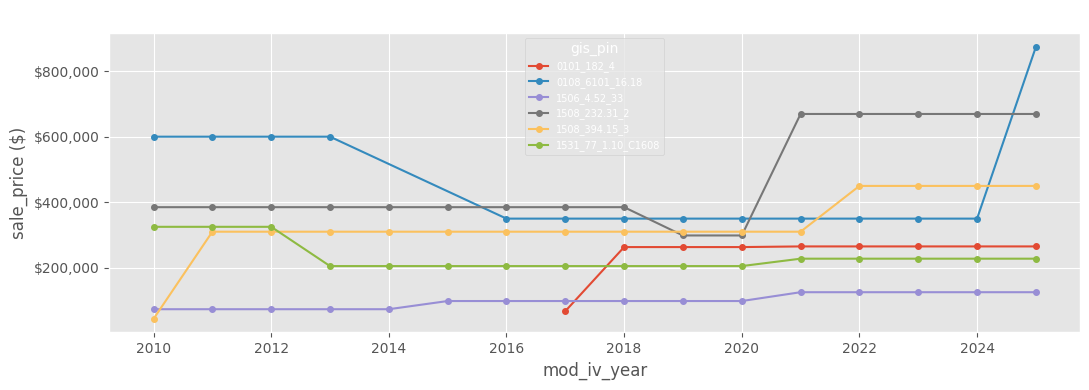

In [14]:
# Example trajectories — a handful of parcels that sold multiple times
example_pins = (parcel_stats[parcel_stats["n_distinct_prices"] >= 3]
                .sample(6, random_state=42)["gis_pin"])

traj = panel[panel["gis_pin"].isin(example_pins)].sort_values(["gis_pin", "mod_iv_year"])

fig, ax = plt.subplots(figsize=(11, 4))
for pin, grp in traj.groupby("gis_pin"):
    ax.plot(grp["mod_iv_year"], grp["sale_price"], marker="o", markersize=4, label=pin)

ax.set_xlabel("mod_iv_year")
ax.set_ylabel("sale_price ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Example parcel sale_price trajectories (parcels with ≥3 distinct prices)")
ax.legend(fontsize=7, title="gis_pin")
plt.tight_layout()
plt.show()